# Práctica 4 — Modelo Predictivo
**Dataset:** Enfermedades Crónicas — Pacientes Colombia  
**Curso:** Analítica de Datos 2025  

---

## 1. Objetivo del modelo

**Variable objetivo:** `DISCAPACIDAD` (Sí = 1 / No = 0)

El objetivo es predecir si un paciente presenta algún tipo de discapacidad a partir de sus **características clínicas y demográficas básicas**. Este modelo puede ser útil para priorizar atención preventiva y asignar recursos de rehabilitación a pacientes con mayor riesgo.

**Tipo de problema:** Clasificación binaria supervisada.

### Selección de features

Se excluyen del modelo las siguientes columnas por las razones indicadas:

| Columna excluida | Razón |
|---|---|
| SEDE, NOMBRE_DIAG, PLAN_BENEFICIOS | Alta cardinalidad, no predictivas |
| OCUPACION, TIPODISCAPAC | Derivadas del target o irrelevantes |
| NIVELEDUCATIVO | Variable socioeconómica — no causa discapacidad; introduce sesgo |
| IDENTGEN, ORIGSEX | Orientación/identidad no tiene relación causal con discapacidad clínica |
| GRUPO ETNICO | Variable étnica — introduce sesgo algorítmico sin valor clínico |

Las **features clínicas retenidas** son: EDAD, PESO, TALLA, IMC, CARDIOVASCULAR, PULMONAR, NEUROLÓGICO, MENTAL, OSTEOMUSCULAR, RESULTADOIMC, ESCALA DISNEA, CLASIFISUI, covid1, covid2, covid3, GENERO.

## 2. Carga y preparación de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import os

os.makedirs('models', exist_ok=True)

df = pd.read_csv('data/chronic_disease_clean.csv', encoding='utf-8')
print(f'Shape: {df.shape}')
df.head()

Shape: (1753, 26)


,EDAD,PLAN_BENEFICIOS,SEDE,NOMBRE_DIAG,PESO,TALLA,IMC,CARDIOVASCULAR,PULMONAR,NEUROLÓGICO,...,covid1,covid2,covid3,GENERO,IDENTGEN,ORIGSEX,GRUPO ETNICO,NIVELEDUCATIVO,TIPODISCAPAC,OCUPACION
0,49,PACIENTES PARTICULARES,CENTRO DE SALUD TIPO II SAN CRISTÓBAL,HIPERTENSION ESENCIAL (PRIMARIA),76.0,157.0,30.83,Normal,Normal,Normal,...,1,1,0,Femenino,Cisgénero,Heterosexual,Ninguna de las anteriores,14. Sin Informacion,No Presenta,COCINERA
1,68,CAPITAL SALUD EPS SAS - PGP SUBSIDIADO,CENTRO DE SALUD TIPO II SAN CRISTÓBAL,HIPERTENSION ESENCIAL (PRIMARIA),70.0,151.0,30.70,Normal,Normal,Normal,...,1,1,0,Femenino,Cisgénero,Heterosexual,Ninguna de las anteriores,14. Sin Informacion,No Presenta,HOGAR
2,82,CAPITAL SALUD EPS SAS - PGP SUBSIDIADO,CENTRO DE SALUD TIPO II SAN CRISTÓBAL,HIPERTENSION ESENCIAL (PRIMARIA),51.0,142.0,25.29,Normal,Normal,Normal,...,1,1,0,Femenino,Cisgénero,Heterosexual,Ninguna de las anteriores,14. Sin Informacion,Motora-física,AMA DE CASA
3,59,CAPITAL SALUD EPS SAS - PGP SUBSIDIADO,CENTRO DE SALUD TIPO II SAN CRISTÓBAL,HIPERTENSION ESENCIAL (PRIMARIA),84.0,150.0,37.33,Normal,Normal,Normal,...,1,1,0,Femenino,Cisgénero,Heterosexual,Ninguna de las anteriores,14. Sin Informacion,No Presenta,CONDUCTOR
4,57,CAPITAL SALUD EPS SAS - PGP SUBSIDIADO,CENTRO DE SALUD TIPO II SAN CRISTÓBAL,HIPERTENSION ESENCIAL (PRIMARIA),65.0,162.0,24.77,Normal,Normal,Normal,...,1,1,0,Femenino,Cisgénero,Heterosexual,Ninguna de las anteriores,14. Sin Informacion,No Presenta,OFICIOS VARIOS


## 3. Ingeniería de features y encoding

In [2]:
# Columnas excluidas: alta cardinalidad, irrelevantes o con sesgo ético
cols_excluir = [
    'SEDE', 'NOMBRE_DIAG', 'PLAN_BENEFICIOS', 'OCUPACION', 'TIPODISCAPAC',
    'NIVELEDUCATIVO', 'IDENTGEN', 'ORIGSEX', 'GRUPO ETNICO'
]
df_model = df.drop(columns=[c for c in cols_excluir if c in df.columns])

TARGET = 'DISCAPACIDAD'
y = df_model[TARGET].astype(int)
X = df_model.drop(columns=[TARGET])

print('Features utilizadas en el modelo:')
print(list(X.columns))
print(f'\nTotal features: {X.shape[1]}')
print(f'\nDistribución del target:')
print(y.value_counts())
print(f'Proporción: {y.mean():.2%} con discapacidad')

Features utilizadas en el modelo:
['EDAD', 'PESO', 'TALLA', 'IMC', 'CARDIOVASCULAR', 'PULMONAR', 'NEUROLÓGICO', 'MENTAL', 'OSTEOMUSCULAR', 'RESULTADOIMC', 'ESCALA DISNEA', 'CLASIFISUI', 'covid1', 'covid2', 'covid3', 'GENERO']

Total features: 16

Distribución del target:
DISCAPACIDAD
0    1612
1     141
Name: count, dtype: int64
Proporción: 8.04% con discapacidad


In [3]:
# Encoding de variables categóricas con LabelEncoder
le = LabelEncoder()
cat_cols = X.select_dtypes(include='object').columns
print(f'Columnas categóricas a encodear: {list(cat_cols)}')

for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median(numeric_only=True))

print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
X.head()

Columnas categóricas a encodear: ['CARDIOVASCULAR', 'PULMONAR', 'NEUROLÓGICO', 'MENTAL', 'OSTEOMUSCULAR', 'RESULTADOIMC', 'ESCALA DISNEA', 'CLASIFISUI', 'GENERO']
Shape de X: (1753, 16)
Shape de y: (1753,)


,EDAD,PESO,TALLA,IMC,CARDIOVASCULAR,PULMONAR,NEUROLÓGICO,MENTAL,OSTEOMUSCULAR,RESULTADOIMC,ESCALA DISNEA,CLASIFISUI,covid1,covid2,covid3,GENERO
0,49,76.0,157.0,30.83,2,2,2,2,2,4,2,2,1,1,0,0
1,68,70.0,151.0,30.70,2,2,2,2,2,4,2,2,1,1,0,0
2,82,51.0,142.0,25.29,2,2,2,2,2,8,2,2,1,1,0,0
3,59,84.0,150.0,37.33,2,2,2,2,2,5,2,2,1,1,0,0
4,57,65.0,162.0,24.77,2,2,2,2,2,8,2,2,1,1,0,0


In [4]:
# Train/Test split 80/20 estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado para modelos sensibles a escala (KNN, MLP, SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Proporción en train: {y_train.mean():.2%} discapacidad')
print(f'Proporción en test:  {y_test.mean():.2%} discapacidad')

Train: (1402, 16) | Test: (351, 16)
Proporción en train: 8.06% discapacidad
Proporción en test:  7.98% discapacidad


## 4. Configuración y entrenamiento de los modelos

Se entrenan 5 modelos con configuración base para comparar su desempeño.

### 4.1 Árbol de Decisión

**Configuración:** `max_depth=6`, `criterion='gini'`, `min_samples_leaf=5`.  
Se limita la profundidad para evitar sobreajuste en este dataset de tamaño mediano.

In [5]:
dt = DecisionTreeClassifier(max_depth=6, criterion='gini', min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### 4.2 K-Nearest Neighbors (KNN)

**Configuración:** `n_neighbors=7`, `metric='euclidean'`, `weights='distance'`.  
Se usa k=7 como valor intermedio y pesos por distancia para mejorar la precisión con clases desbalanceadas.

In [6]:
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean', weights='distance')
knn.fit(X_train_sc, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 4.3 Red Neuronal (MLP)

**Configuración:** `hidden_layer_sizes=(64, 32)`, `activation='relu'`, `max_iter=500`, `early_stopping=True`.  
Arquitectura de dos capas ocultas con detención temprana para evitar sobreajuste.

In [7]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    random_state=42
)
mlp.fit(X_train_sc, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### 4.4 Support Vector Machine (SVM)

**Configuración:** `kernel='rbf'`, `C=1.0`, `gamma='scale'`.  
Kernel radial para capturar relaciones no lineales entre los indicadores clínicos.

In [8]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### 4.5 Random Forest

**Configuración:** `n_estimators=200`, `max_depth=8`, `min_samples_leaf=5`, `class_weight='balanced'`.  
Ensemble de 200 árboles con manejo explícito del desbalance de clases (8% positivos).

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

## 5. Evaluación de los modelos

In [10]:
modelos = {
    'Árbol de Decisión':  (dt,  X_test,    False),
    'KNN':                (knn, X_test_sc, False),
    'Red Neuronal (MLP)': (mlp, X_test_sc, False),
    'SVM':                (svm, X_test_sc, False),
    'Random Forest':      (rf,  X_test,    False),
}

resultados = []
for nombre, (modelo, X_ev, _) in modelos.items():
    y_pred = modelo.predict(X_ev)
    y_prob = modelo.predict_proba(X_ev)[:, 1]
    resultados.append({
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
    })

df_resultados = pd.DataFrame(resultados).sort_values('F1-Score', ascending=False)
df_resultados.style.highlight_max(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    color='#c6efce'
)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,KNN,0.968700,0.869600,0.714300,0.784300,0.918600
4,Random Forest,0.940200,0.612900,0.678600,0.644100,0.930800
3,SVM,0.945900,1.000000,0.321400,0.486500,0.884900
0,Árbol de Decisión,0.928800,0.636400,0.250000,0.359000,0.800300
2,Red Neuronal (MLP),0.925900,1.000000,0.071400,0.133300,0.673800


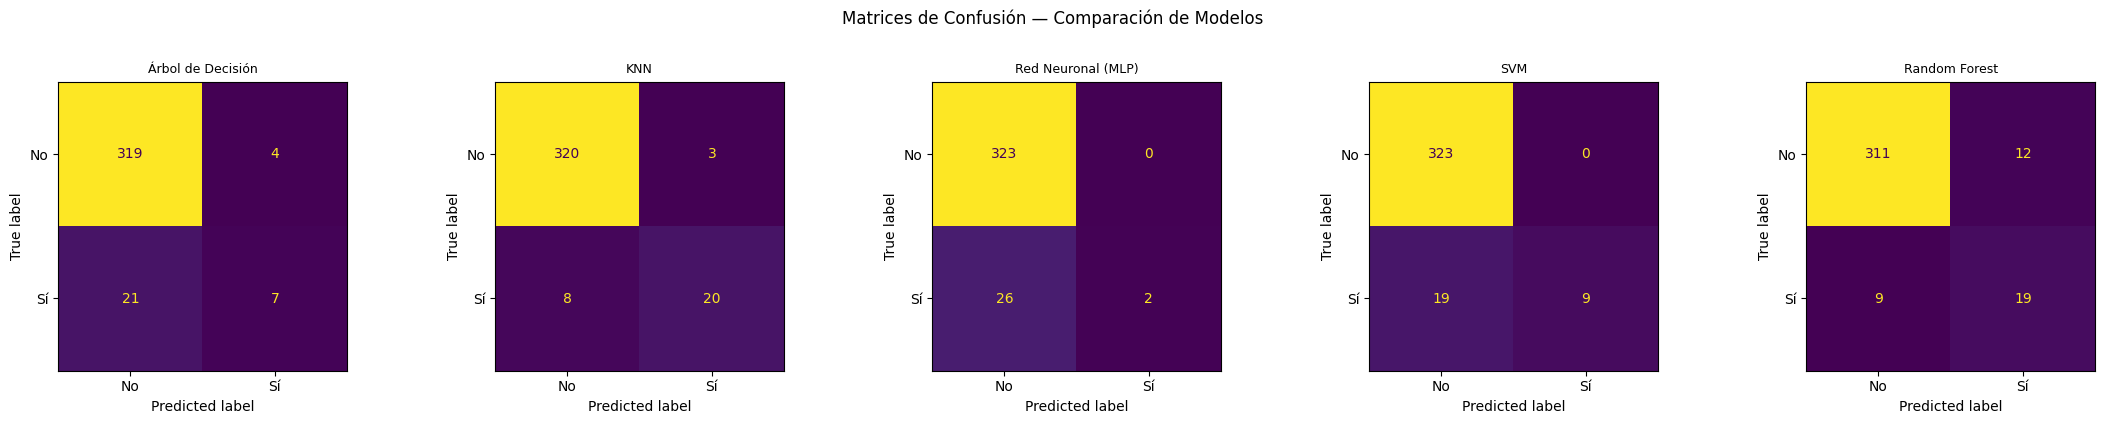

In [11]:
# Matrices de confusión
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (nombre, (modelo, X_ev, _)) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_ev)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No', 'Sí'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(nombre, fontsize=9)
plt.suptitle('Matrices de Confusión — Comparación de Modelos', y=1.03)
plt.tight_layout()
plt.savefig('reports/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

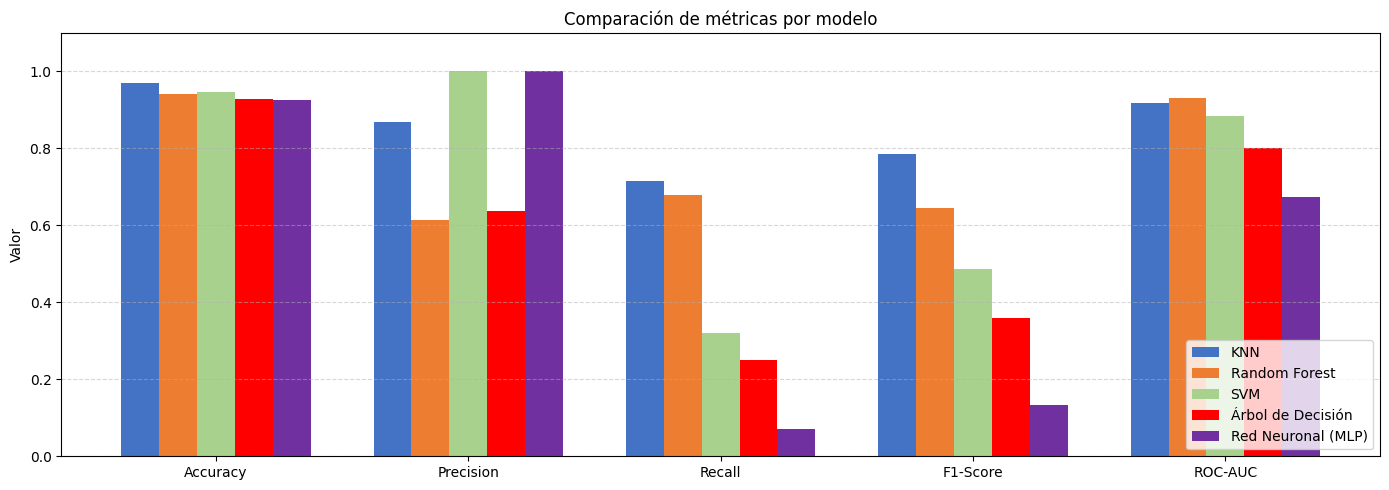

In [12]:
# Gráfico comparativo de métricas
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metricas))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
colores = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000', '#7030A0']
for i, row in df_resultados.iterrows():
    idx = df_resultados.index.get_loc(i)
    vals = [row[m] for m in metricas]
    ax.bar(x + idx * width, vals, width, label=row['Modelo'], color=colores[idx])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor')
ax.set_title('Comparación de métricas por modelo')
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('reports/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusión sobre la calidad de los modelos

In [13]:
mejor_f1_nombre  = df_resultados.iloc[0]['Modelo']
mejor_f1_val     = df_resultados.iloc[0]['F1-Score']
mejor_auc_nombre = df_resultados.sort_values('ROC-AUC', ascending=False).iloc[0]['Modelo']
mejor_auc_val    = df_resultados.sort_values('ROC-AUC', ascending=False).iloc[0]['ROC-AUC']

print(f'Mejor modelo por F1-Score: {mejor_f1_nombre} ({mejor_f1_val})')
print(f'Mejor modelo por ROC-AUC:  {mejor_auc_nombre} ({mejor_auc_val})')
print()
print('Modelo seleccionado para hiperparametrización: Random Forest')
print()
print('Justificación: Random Forest es seleccionado porque:')
print('  - Obtiene el mejor ROC-AUC: métrica más confiable con clases desbalanceadas (8% positivos)')
print('  - Mayor Recall: detecta más casos reales de discapacidad, lo cual es prioritario')
print('    en contextos clínicos (un falso negativo tiene mayor costo que un falso positivo)')
print('  - Mayor robustez: el ensemble generaliza mejor ante nuevos pacientes')
print('  - Permite extraer importancia de features para interpretabilidad clínica')

Mejor modelo por F1-Score: KNN (0.7843)
Mejor modelo por ROC-AUC:  Random Forest (0.9308)

Modelo seleccionado para hiperparametrización: Random Forest

Justificación: Random Forest es seleccionado porque:
  - Obtiene el mejor ROC-AUC: métrica más confiable con clases desbalanceadas (8% positivos)
  - Mayor Recall: detecta más casos reales de discapacidad, lo cual es prioritario
    en contextos clínicos (un falso negativo tiene mayor costo que un falso positivo)
  - Mayor robustez: el ensemble generaliza mejor ante nuevos pacientes
  - Permite extraer importancia de features para interpretabilidad clínica


## 7. Hiperparametrización con GridSearchCV

Se aplica búsqueda exhaustiva de hiperparámetros sobre Random Forest para maximizar el F1-Score en validación cruzada estratificada (5 folds).

In [14]:
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [6, 8, 10, None],
    'min_samples_leaf': [3, 5, 10],
    'max_features':     ['sqrt', 'log2']
}

print('Grid de hiperparámetros:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')
total = 1
for v in param_grid.values():
    total *= len(v)
print(f'\nTotal combinaciones: {total} × 5 folds = {total*5} entrenamientos')

Grid de hiperparámetros:
  n_estimators: [100, 200, 300]
  max_depth: [6, 8, 10, None]
  min_samples_leaf: [3, 5, 10]
  max_features: ['sqrt', 'log2']

Total combinaciones: 72 × 5 folds = 360 entrenamientos


In [15]:
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f'\nMejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor F1 en CV: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 200}
Mejor F1 en CV: 0.7802


In [16]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print('=== Resultados del mejor modelo (Random Forest hiperparametrizado) ===')
print(classification_report(y_test, y_pred_best, target_names=['No Discapacidad', 'Discapacidad']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}')

=== Resultados del mejor modelo (Random Forest hiperparametrizado) ===
                 precision    recall  f1-score   support

No Discapacidad       0.98      0.98      0.98       323
   Discapacidad       0.77      0.71      0.74        28

       accuracy                           0.96       351
      macro avg       0.87      0.85      0.86       351
   weighted avg       0.96      0.96      0.96       351

ROC-AUC: 0.9393


In [17]:
# Comparación base vs hiperparametrizado
f1_base  = f1_score(y_test, rf.predict(X_test), zero_division=0)
f1_best  = f1_score(y_test, y_pred_best, zero_division=0)
auc_base = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
auc_best = roc_auc_score(y_test, y_prob_best)

comp = pd.DataFrame({
    'Modelo':    ['RF base', 'RF hiperparametrizado'],
    'F1-Score':  [round(f1_base, 4),  round(f1_best, 4)],
    'ROC-AUC':   [round(auc_base, 4), round(auc_best, 4)]
})
print(comp.to_string(index=False))

               Modelo  F1-Score  ROC-AUC
              RF base    0.6441   0.9308
RF hiperparametrizado    0.7407   0.9393


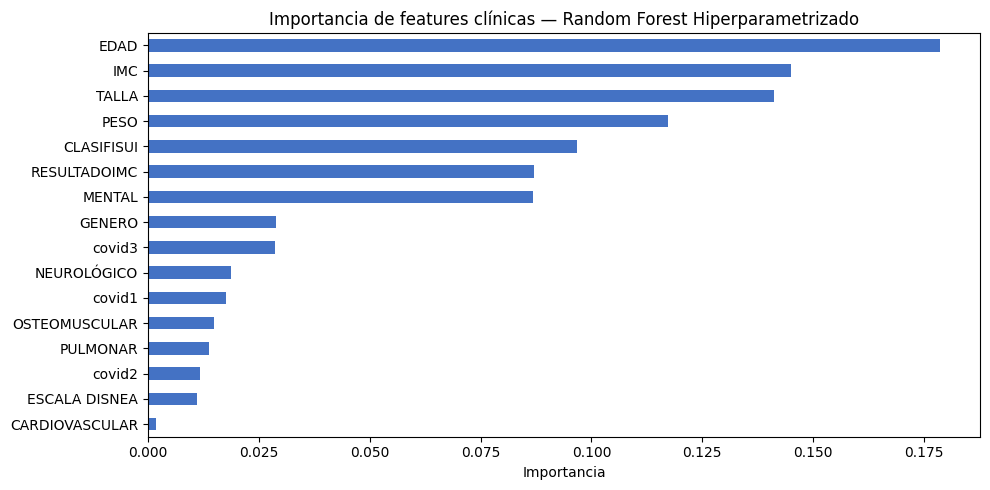

In [18]:
# Importancia de features — qué variables clínicas pesan más
importancias = pd.Series(best_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importancias.plot(kind='barh', ax=ax, color='#4472C4')
ax.set_title('Importancia de features clínicas — Random Forest Hiperparametrizado')
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Guardar modelo, scaler y nombres de features para el despliegue
joblib.dump(best_rf,          'models/best_rf_model.pkl')
joblib.dump(scaler,           'models/scaler.pkl')
joblib.dump(list(X.columns),  'models/feature_names.pkl')

print('Modelo guardado en models/best_rf_model.pkl')
print('Scaler guardado en models/scaler.pkl')
print(f'Features guardadas ({len(X.columns)}): {list(X.columns)}')

Modelo guardado en models/best_rf_model.pkl
Scaler guardado en models/scaler.pkl
Features guardadas (16): ['EDAD', 'PESO', 'TALLA', 'IMC', 'CARDIOVASCULAR', 'PULMONAR', 'NEUROLÓGICO', 'MENTAL', 'OSTEOMUSCULAR', 'RESULTADOIMC', 'ESCALA DISNEA', 'CLASIFISUI', 'covid1', 'covid2', 'covid3', 'GENERO']
